
# Grid- World Robot with with A*,Dijkstra and BFS Path Planning


In this notebok, the code of the project is being presented in small readable sections. For more information about the project, please refer to the written report.

________________________________________________________________________________________________


There are 4 cases examined in this project. The code will be provided seperately for each case.

##  Simple pathfinding case: 

### Same obstacles on a 2D grid. Route beatween a starting and an ending point.

Firstly, all the necessary libraries are imported.

In [18]:
import heapq
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

________________________________________________________________________________________________

Then, there is the setup of a 2D grid 30 X 30 size. Each cell is either empty or an obstacle. The chance of being an obstacle is 25%.

In [19]:
GRID_SIZE = 30
OBSTACLE_PROB = 0.25

def generate_grid(size, obstacle_prob):
    grid = np.zeros((size, size))
    for i in range(size):
        for j in range(size):
            if random.random() < obstacle_prob:
                grid[i][j] = 1
    return grid


This function finds valid adjacent cells the robot can move to. The robot is allowed to a 4 directional movement: up, down, left, right. No diagonal movements are allowed .

In [20]:
def get_neighbors(node, grid):
    x, y = node
    neighbors = []
    directions = [(1,0), (-1,0), (0,1), (0,-1)]
    for dx, dy in directions:
        nx, ny = x + dx, y + dy
        if 0 <= nx < grid.shape[0] and 0 <= ny < grid.shape[1]:
            if grid[nx][ny] == 0:
                neighbors.append((nx, ny))
    return neighbors


This function rebuilds the path from start to finish, after each algorithm reaches the goal.

In [21]:
def reconstruct_path(came_from, start, goal):
    path = []
    current = goal
    while current != start:
        path.append(current)
        current = came_from[current]
    path.append(start)
    path.reverse()
    return path

________________________________________________________________________________________________

BFS algorithm is first implemented. At the end, total runtime is calculated and the path is built, returing the number of nodes expanded and the path length. 

In [22]:
def bfs(grid, start, goal):
    queue = deque([start])
    visited = set([start])
    came_from = {}
    nodes_expanded = 0

    start_time = time.time()

    while queue:
        current = queue.popleft()
        nodes_expanded += 1

        if current == goal:
            runtime = time.time() - start_time
            path = reconstruct_path(came_from, start, goal)
            return path, nodes_expanded, runtime

        for neighbor in get_neighbors(current, grid):
            if neighbor not in visited:
                visited.add(neighbor)
                came_from[neighbor] = current
                queue.append(neighbor)

    return None, nodes_expanded, time.time() - start_time

Dijkstra's algorithm sets a priority-min queue, so as to store the shortest known distance from the start at this current point.

The results provided are again the total runtime, the number of nodes expanded and the shortest path length.

In [23]:
def dijkstra(grid, start, goal):
    pq = [(0, start)]
    distances = {start: 0}
    came_from = {}
    visited = set()
    nodes_expanded = 0

    start_time = time.time()

    while pq:
        cost, current = heapq.heappop(pq)

        if current in visited:
            continue

        visited.add(current)
        nodes_expanded += 1

        if current == goal:
            runtime = time.time() - start_time
            path = reconstruct_path(came_from, start, goal)
            return path, nodes_expanded, runtime

        for neighbor in get_neighbors(current, grid):
            new_cost = cost + 1
            if neighbor not in distances or new_cost < distances[neighbor]:
                distances[neighbor] = new_cost
                came_from[neighbor] = current
                heapq.heappush(pq, (new_cost, neighbor))

    return None, nodes_expanded, time.time() - start_time

In order to use A* algorithm, the heuristic needs to be defined. 

For this example, and given the fact that diagonal movements are not allowed, the heuristic is set to be equal with the Manhattan distance between two cells. That is:

$$|x_1-x_2|+|y_1-y_2|$$

This means that the cost $ f() $ of a node $n$ is then calculated as:

$$f(n) = g(n) + h(n)$$

where $g(n)$ is the cost so far and $h(n)$ is the estimated cost to the goal.

At the end, the same metrics are shown as for the other two algorithms.

In [24]:
def heuristic(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def astar(grid, start, goal):
    pq = [(0, start)]
    g_cost = {start: 0}
    came_from = {}
    visited = set()
    nodes_expanded = 0

    start_time = time.time()

    while pq:
        _, current = heapq.heappop(pq)

        if current in visited:
            continue

        visited.add(current)
        nodes_expanded += 1

        if current == goal:
            runtime = time.time() - start_time
            path = reconstruct_path(came_from, start, goal)
            return path, nodes_expanded, runtime

        for neighbor in get_neighbors(current, grid):
            tentative_g = g_cost[current] + 1
            if neighbor not in g_cost or tentative_g < g_cost[neighbor]:
                g_cost[neighbor] = tentative_g
                f_cost = tentative_g + heuristic(neighbor, goal)
                came_from[neighbor] = current
                heapq.heappush(pq, (f_cost, neighbor))

    return None, nodes_expanded, time.time() - start_time

________________________________________________________________________________________________

This function visualizes the grid and the path found by an algorithm using the library Matplotlib.

In [25]:
def visualize(grid, path, start, goal, title):
    display = np.copy(grid)
    if path:
        for x, y in path:
            display[x][y] = 0.5
    display[start] = 0.7
    display[goal] = 0.9

    plt.imshow(display, cmap="viridis")
    plt.title(title)
    plt.colorbar()
    plt.show()


________________________________________________________________________________________________

The grid is generated, the robot starts its path at (0,0) and finishes at (29,29). Since obstacles are random, the start and finish are guaranteed to be empty cells.

Each algorithm is run and the results are returned both in numeric and in visual formats.


BFS Results:
Path Length: 59
Nodes Expanded: 679
Runtime: 0.001621 seconds


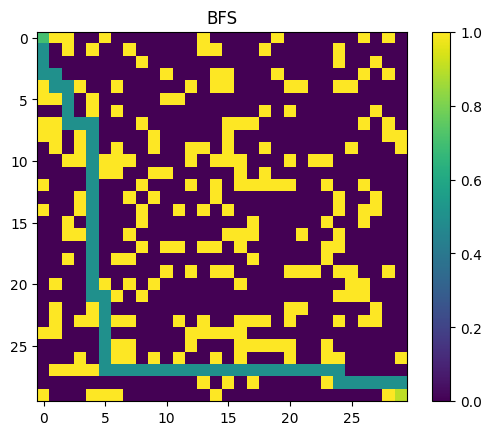


Dijkstra Results:
Path Length: 59
Nodes Expanded: 679
Runtime: 0.001747 seconds


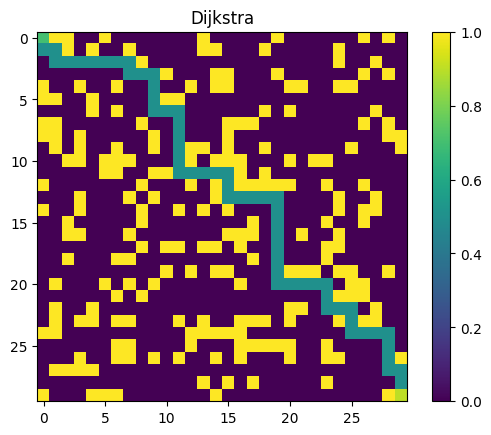


A* Results:
Path Length: 59
Nodes Expanded: 351
Runtime: 0.001101 seconds


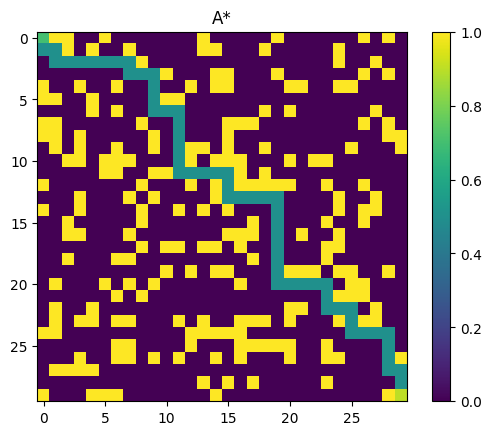


=== Comparison Table ===
BFS: {'Path Length': 59, 'Nodes Expanded': 679, 'Runtime (s)': 0.0016214847564697266}
Dijkstra: {'Path Length': 59, 'Nodes Expanded': 679, 'Runtime (s)': 0.0017466545104980469}
A*: {'Path Length': 59, 'Nodes Expanded': 351, 'Runtime (s)': 0.0011010169982910156}


In [26]:
def main():
    grid = generate_grid(GRID_SIZE, OBSTACLE_PROB)

    start = (0, 0)
    goal = (GRID_SIZE - 1, GRID_SIZE - 1)

    grid[start] = 0
    grid[goal] = 0

    results = {}

    for name, algo in [("BFS", bfs), ("Dijkstra", dijkstra), ("A*", astar)]:
        path, nodes, runtime = algo(grid, start, goal)
        if path:
            results[name] = {
                "Path Length": len(path),
                "Nodes Expanded": nodes,
                "Runtime (s)": runtime
            }
            print(f"\n{name} Results:")
            print(f"Path Length: {len(path)}")
            print(f"Nodes Expanded: {nodes}")
            print(f"Runtime: {runtime:.6f} seconds")

            visualize(grid, path, start, goal, name)
        else:
            print(f"{name} failed to find a path.")

    print("\n=== Comparison Table ===")
    for name, metrics in results.items():
        print(f"{name}: {metrics}")

if __name__ == "__main__":
    main()

 _______________________________________________________________________________________________

## Weighted Pathfinding case:

### Same obstacles on a 2D grid. Route beatween a starting and an ending point. Terrain carries different weights accorind to its colour: 

#### 1= water, 2= grass, 3=land 

Importing libraries.

In [1]:
import heapq
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import deque


________________________________________________________________________________________________

Grid, obstacles and weights setup.

In [2]:
GRID_SIZE = 30
OBSTACLE_PROB = 0.15  # lower probability to make paths more likely
TERRAIN_WEIGHTS = [1, 2, 3]  # terrain costs

Grid generation.

In [3]:
def generate_grid(size, obstacle_prob):
    grid = np.zeros((size, size))
    for i in range(size):
        for j in range(size):
            if random.random() < obstacle_prob:
                grid[i][j] = -1  # obstacle
            else:
                grid[i][j] = random.choice(TERRAIN_WEIGHTS)
    return grid

def get_neighbors(node, grid):
    x, y = node
    neighbors = []
    directions = [(1,0), (-1,0), (0,1), (0,-1)]
    for dx, dy in directions:
        nx, ny = x + dx, y + dy
        if 0 <= nx < grid.shape[0] and 0 <= ny < grid.shape[1]:
            if grid[nx][ny] != -1:
                neighbors.append((nx, ny))
    return neighbors

Path reconstuction.

In [4]:
def reconstruct_path(came_from, start, goal):
    path = []
    current = goal
    while current != start:
        path.append(current)
        current = came_from[current]
    path.append(start)
    path.reverse()
    return path

________________________________________________________________________________________________

BFS algorithm script is the same as before, due to the fact that it does not take accountability of the weights in its calculations. The algorithm chooses the shortest path regardless of the weights.

In [5]:
def bfs(grid, start, goal):
    queue = deque([start])
    visited = set([start])
    came_from = {}
    nodes_expanded = 0
    start_time = time.time()
    while queue:
        current = queue.popleft()
        nodes_expanded += 1
        if current == goal:
            runtime = time.time() - start_time
            return reconstruct_path(came_from, start, goal), nodes_expanded, runtime
        for neighbor in get_neighbors(current, grid):
            if neighbor not in visited:
                visited.add(neighbor)
                came_from[neighbor] = current
                queue.append(neighbor)
    return None, nodes_expanded, time.time() - start_time


However, that is not the case for Dijkstra's and A* algorithms.

In [6]:
def dijkstra(grid, start, goal):
    pq = [(grid[start], start)]
    distances = {start: grid[start]}
    came_from = {}
    visited = set()
    nodes_expanded = 0
    start_time = time.time()
    while pq:
        cost, current = heapq.heappop(pq)
        if current in visited:
            continue
        visited.add(current)
        nodes_expanded += 1
        if current == goal:
            runtime = time.time() - start_time
            return reconstruct_path(came_from, start, goal), nodes_expanded, runtime
        for neighbor in get_neighbors(current, grid):
            new_cost = cost + grid[neighbor]
            if neighbor not in distances or new_cost < distances[neighbor]:
                distances[neighbor] = new_cost
                came_from[neighbor] = current
                heapq.heappush(pq, (new_cost, neighbor))
    return None, nodes_expanded, time.time() - start_time

In [7]:
def heuristic(a, b):
    return abs(a[0]-b[0]) + abs(a[1]-b[1])

def astar(grid, start, goal):
    pq = [(grid[start] + heuristic(start, goal), start)]
    g_cost = {start: grid[start]}
    came_from = {}
    visited = set()
    nodes_expanded = 0
    start_time = time.time()
    while pq:
        _, current = heapq.heappop(pq)
        if current in visited:
            continue
        visited.add(current)
        nodes_expanded += 1
        if current == goal:
            runtime = time.time() - start_time
            return reconstruct_path(came_from, start, goal), nodes_expanded, runtime
        for neighbor in get_neighbors(current, grid):
            tentative_g = g_cost[current] + grid[neighbor]
            if neighbor not in g_cost or tentative_g < g_cost[neighbor]:
                g_cost[neighbor] = tentative_g
                f_cost = tentative_g + heuristic(neighbor, goal)
                came_from[neighbor] = current
                heapq.heappush(pq, (f_cost, neighbor))
    return None, nodes_expanded, time.time() - start_time

________________________________________________________________________________________________

The colours in the visualisation will now be a little different, because there were added colours on the terrain as well. Obstacles are still present.

In [8]:
def visualize(grid, path, start, goal, title):
    display = np.copy(grid)
    display[display == -1] = np.nan  # obstacles as NaN for black

    cmap = plt.cm.viridis
    cmap.set_bad(color='black')

    plt.figure(figsize=(6,6))
    plt.imshow(display, cmap=cmap)

    if path:
        for x, y in path:
            plt.plot(y, x, marker='s', color='red', markersize=8)

    plt.plot(start[1], start[0], marker='o', color='green', markersize=10, label='Start')
    plt.plot(goal[1], goal[0], marker='o', color='blue', markersize=10, label='Goal')

    plt.title(title)
    plt.colorbar(label="Terrain Cost")
    plt.legend(loc='upper left')
    plt.show()


_______________________________________________________________________________________________

The main function remains the same, with a small add-on, which ensures retrial of the grid generation until a path exists.


BFS Results:
Path Length: 59
Nodes Expanded: 753
Runtime: 0.002028 seconds


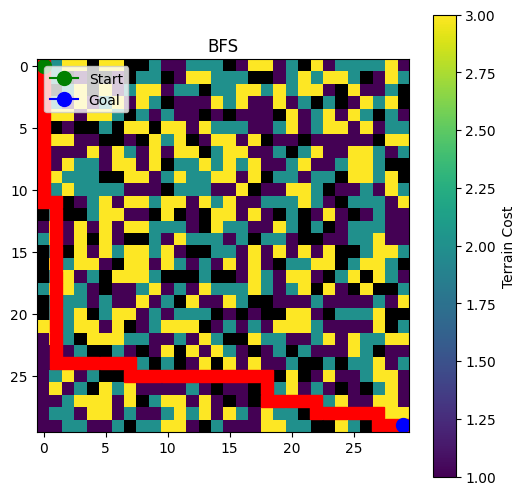


Dijkstra Results:
Path Length: 61
Nodes Expanded: 752
Runtime: 0.002350 seconds


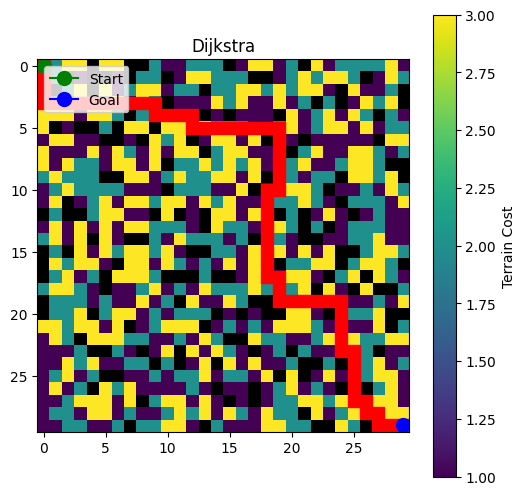


A* Results:
Path Length: 61
Nodes Expanded: 673
Runtime: 0.002439 seconds


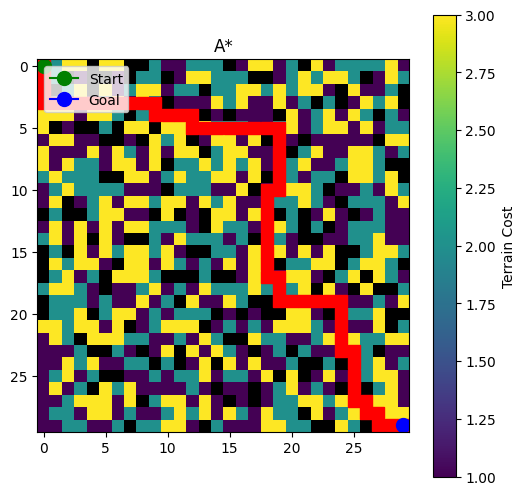


=== Comparison Table ===
BFS: {'Path Length': 59, 'Nodes Expanded': 753, 'Runtime (s)': 0.0020275115966796875}
Dijkstra: {'Path Length': 61, 'Nodes Expanded': 752, 'Runtime (s)': 0.0023496150970458984}
A*: {'Path Length': 61, 'Nodes Expanded': 673, 'Runtime (s)': 0.0024394989013671875}


In [9]:
def main():
    start = (0, 0)
    goal = (GRID_SIZE-1, GRID_SIZE-1)

    # Retry grid generation until a path exists
    while True:
        grid = generate_grid(GRID_SIZE, OBSTACLE_PROB)
        grid[start] = 1
        grid[goal] = 1
        path, _, _ = astar(grid, start, goal)
        if path:
            break

    results = {}

    for name, algo in [("BFS", bfs), ("Dijkstra", dijkstra), ("A*", astar)]:
        path, nodes, runtime = algo(grid, start, goal)
        if path:
            results[name] = {
                "Path Length": len(path),
                "Nodes Expanded": nodes,
                "Runtime (s)": runtime
            }
            print(f"\n{name} Results:")
            print(f"Path Length: {len(path)}")
            print(f"Nodes Expanded: {nodes}")
            print(f"Runtime: {runtime:.6f} seconds")
            visualize(grid, path, start, goal, name)
        else:
            print(f"{name} failed to find a path.")

    print("\n=== Comparison Table ===")
    for name, metrics in results.items():
        print(f"{name}: {metrics}")

if __name__ == "__main__":
    main()

________________________________________________________________________________________________

## Random generated grids case:

### Random obstacles on a 2D grid. Route beatween a starting and an ending point. Terrain carries again no weights.

The libraries imported and the code for the grid setup and the pathfinding by using the 3 algortihms are the same as in the simple case.

In [10]:
import heapq
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

GRID_SIZE = 30
OBSTACLE_PROB = 0.25

def generate_grid(size, obstacle_prob):
    grid = np.zeros((size, size))
    for i in range(size):
        for j in range(size):
            if random.random() < obstacle_prob:
                grid[i][j] = 1  # obstacle
    return grid

def get_neighbors(node, grid):
    x, y = node
    neighbors = []
    directions = [(1,0), (-1,0), (0,1), (0,-1)]
    for dx, dy in directions:
        nx, ny = x + dx, y + dy
        if 0 <= nx < grid.shape[0] and 0 <= ny < grid.shape[1]:
            if grid[nx][ny] == 0:
                neighbors.append((nx, ny))
    return neighbors

def reconstruct_path(came_from, start, goal):
    path = []
    current = goal
    while current != start:
        path.append(current)
        current = came_from[current]
    path.append(start)
    path.reverse()
    return path

def bfs(grid, start, goal):
    queue = deque([start])
    visited = set([start])
    came_from = {}
    nodes_expanded = 0
    start_time = time.time()

    while queue:
        current = queue.popleft()
        nodes_expanded += 1

        if current == goal:
            runtime = time.time() - start_time
            return reconstruct_path(came_from, start, goal), nodes_expanded, runtime

        for neighbor in get_neighbors(current, grid):
            if neighbor not in visited:
                visited.add(neighbor)
                came_from[neighbor] = current
                queue.append(neighbor)
    return None, nodes_expanded, time.time() - start_time

def dijkstra(grid, start, goal):
    pq = [(0, start)]
    distances = {start: 0}
    came_from = {}
    visited = set()
    nodes_expanded = 0
    start_time = time.time()

    while pq:
        cost, current = heapq.heappop(pq)
        if current in visited:
            continue

        visited.add(current)
        nodes_expanded += 1

        if current == goal:
            runtime = time.time() - start_time
            return reconstruct_path(came_from, start, goal), nodes_expanded, runtime

        for neighbor in get_neighbors(current, grid):
            new_cost = cost + 1
            if neighbor not in distances or new_cost < distances[neighbor]:
                distances[neighbor] = new_cost
                came_from[neighbor] = current
                heapq.heappush(pq, (new_cost, neighbor))
    return None, nodes_expanded, time.time() - start_time

def heuristic(a, b):
    return abs(a[0]-b[0]) + abs(a[1]-b[1])

def astar(grid, start, goal):
    pq = [(0, start)]
    g_cost = {start: 0}
    came_from = {}
    visited = set()
    nodes_expanded = 0
    start_time = time.time()

    while pq:
        _, current = heapq.heappop(pq)
        if current in visited:
            continue

        visited.add(current)
        nodes_expanded += 1

        if current == goal:
            runtime = time.time() - start_time
            return reconstruct_path(came_from, start, goal), nodes_expanded, runtime

        for neighbor in get_neighbors(current, grid):
            tentative_g = g_cost[current] + 1
            if neighbor not in g_cost or tentative_g < g_cost[neighbor]:
                g_cost[neighbor] = tentative_g
                f_cost = tentative_g + heuristic(neighbor, goal)
                came_from[neighbor] = current
                heapq.heappush(pq, (f_cost, neighbor))
    return None, nodes_expanded, time.time() - start_time


_______________________________________________________________________________________________

For this example, 10 random grids are generated. Of course this variable can always change.

Since there are more than 1 grids, the results will be calculated as average.

In [11]:
def evaluate_algorithms(n_grids=10):
    start = (0,0)
    goal = (GRID_SIZE-1, GRID_SIZE-1)
    algorithms = [("BFS", bfs), ("Dijkstra", dijkstra), ("A*", astar)]
    results = {name: {"Path Length": [], "Nodes Expanded": [], "Runtime": []} for name,_ in algorithms}
    grids_and_paths = []  # store grids and paths for visualization

    for i in range(n_grids):
        while True:  # ensure at least one path exists
            grid = generate_grid(GRID_SIZE, OBSTACLE_PROB)
            grid[start] = 0
            grid[goal] = 0
            path, _, _ = astar(grid, start, goal)
            if path:
                break

        grid_result = {"grid": grid, "paths": {}}

        for name, algo in algorithms:
            path, nodes, runtime = algo(grid, start, goal)
            grid_result["paths"][name] = path
            results[name]["Path Length"].append(len(path))
            results[name]["Nodes Expanded"].append(nodes)
            results[name]["Runtime"].append(runtime)

        grids_and_paths.append(grid_result)

    # Print average metrics
    for name in results:
        avg_len = np.mean(results[name]["Path Length"])
        avg_nodes = np.mean(results[name]["Nodes Expanded"])
        avg_runtime = np.mean(results[name]["Runtime"])
        print(f"\n{name} Average over {n_grids} grids:")
        print(f"Average Path Length: {avg_len:.2f}")
        print(f"Average Nodes Expanded: {avg_nodes:.2f}")
        print(f"Average Runtime (s): {avg_runtime:.6f}")

    return grids_and_paths, results

________________________________________________________________________________________________

For each one of the 10 random grids, the paths found by the 3 algorithms will be shown side by side for easier comparison.

In [12]:
def show_all_grids_side_by_side(grids_and_paths, algorithms=["BFS","Dijkstra","A*"]):
    n_grids = len(grids_and_paths)
    
    for i, grid_info in enumerate(grids_and_paths):
        fig, axs = plt.subplots(1, len(algorithms), figsize=(5*len(algorithms),5))
        if len(algorithms) == 1:
            axs = [axs]  # ensure iterable
        grid = grid_info["grid"]
        
        for ax, algo_name in zip(axs, algorithms):
            path = grid_info["paths"][algo_name]
            ax.imshow(grid, cmap="viridis")
            
            if path:
                for x, y in path:
                    ax.plot(y, x, marker='s', color='red', markersize=4)
            
            ax.plot(0,0, marker='o', color='green', markersize=6)  # start
            ax.plot(GRID_SIZE-1, GRID_SIZE-1, marker='o', color='blue', markersize=6)  # goal
            ax.set_title(f"{algo_name}")
            ax.axis('off')
        
        plt.suptitle(f"Grid {i+1} - BFS vs Dijkstra vs A*", fontsize=16)
        plt.tight_layout(rect=[0,0,1,0.95])
        plt.show()


BFS Average over 10 grids:
Average Path Length: 59.00
Average Nodes Expanded: 667.70
Average Runtime (s): 0.001527

Dijkstra Average over 10 grids:
Average Path Length: 59.00
Average Nodes Expanded: 668.20
Average Runtime (s): 0.001768

A* Average over 10 grids:
Average Path Length: 59.00
Average Nodes Expanded: 337.30
Average Runtime (s): 0.000994


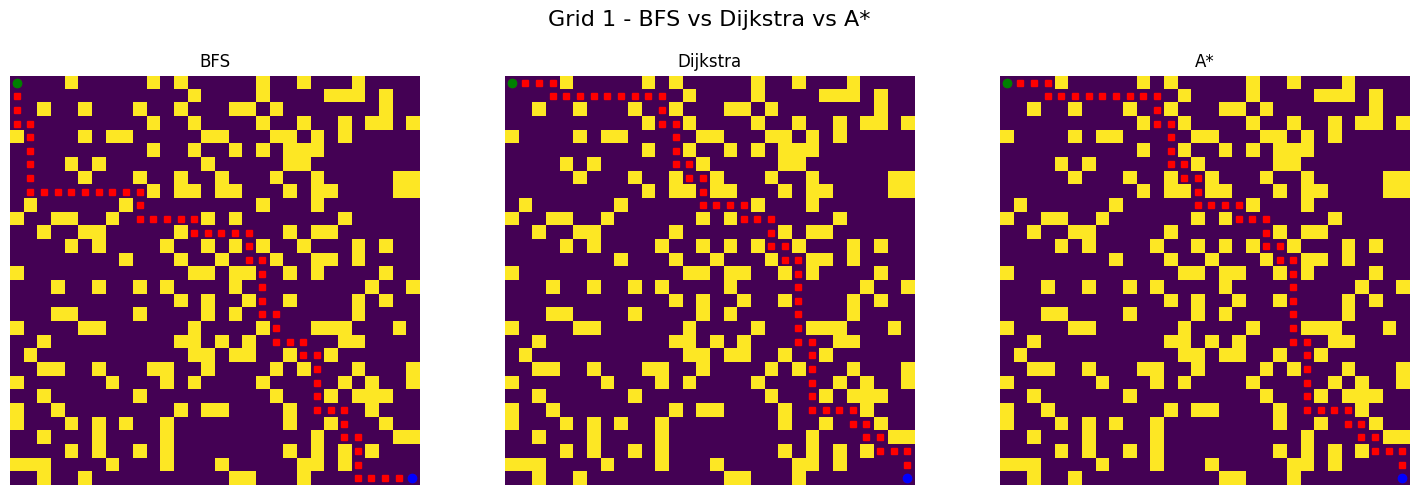

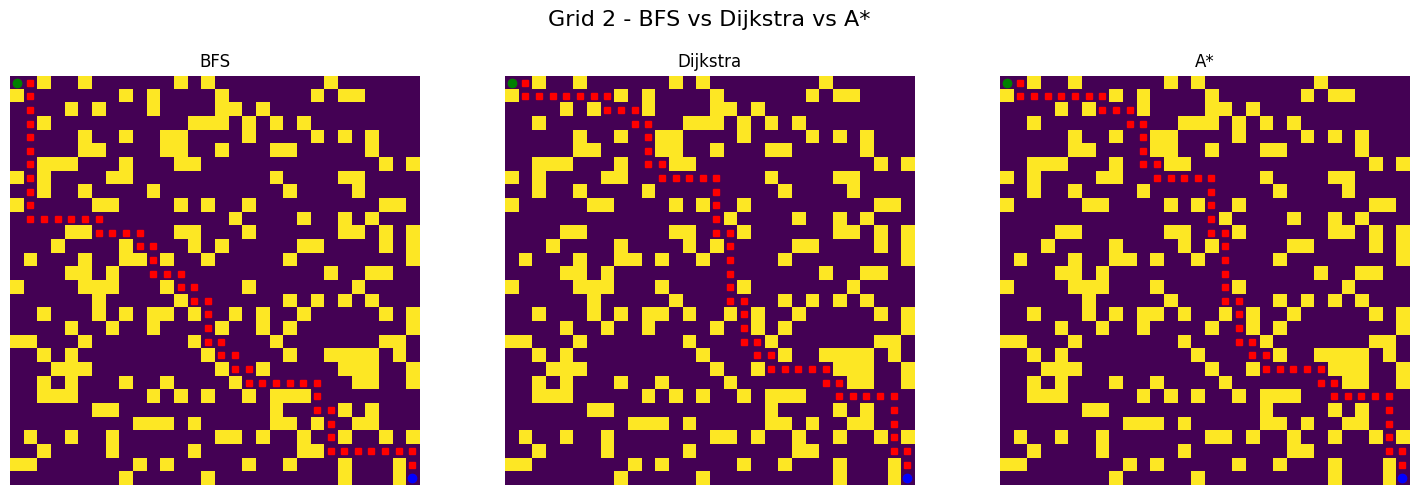

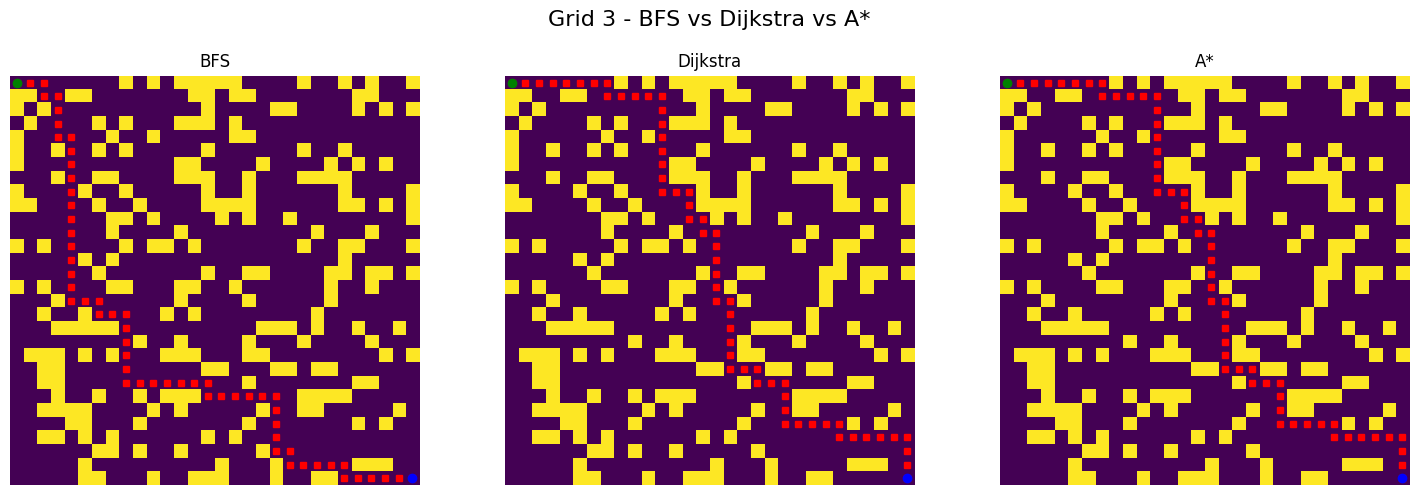

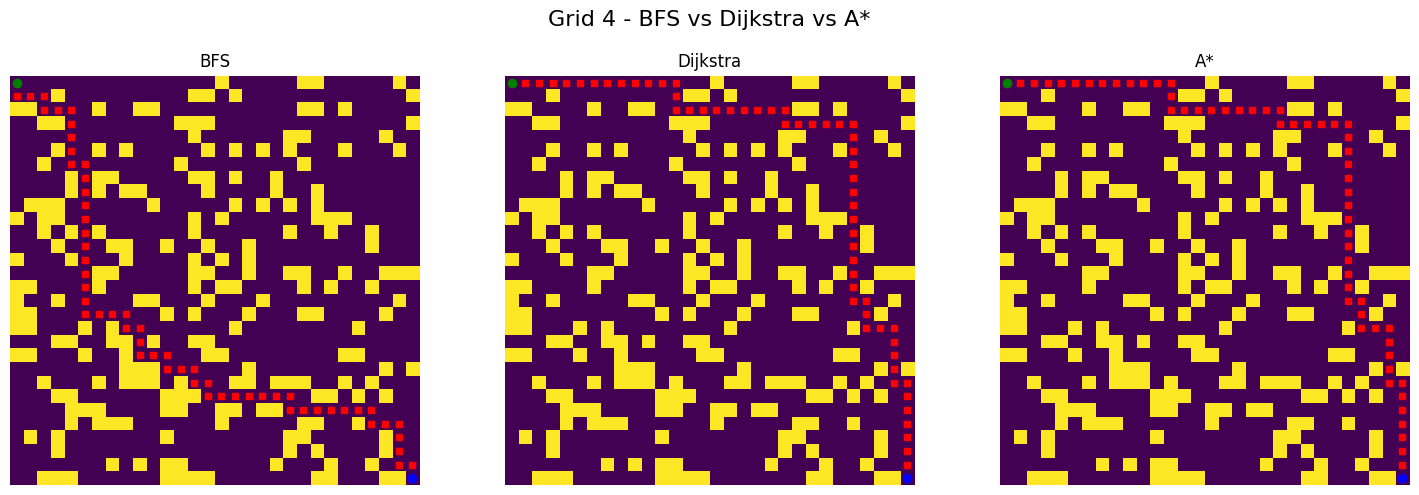

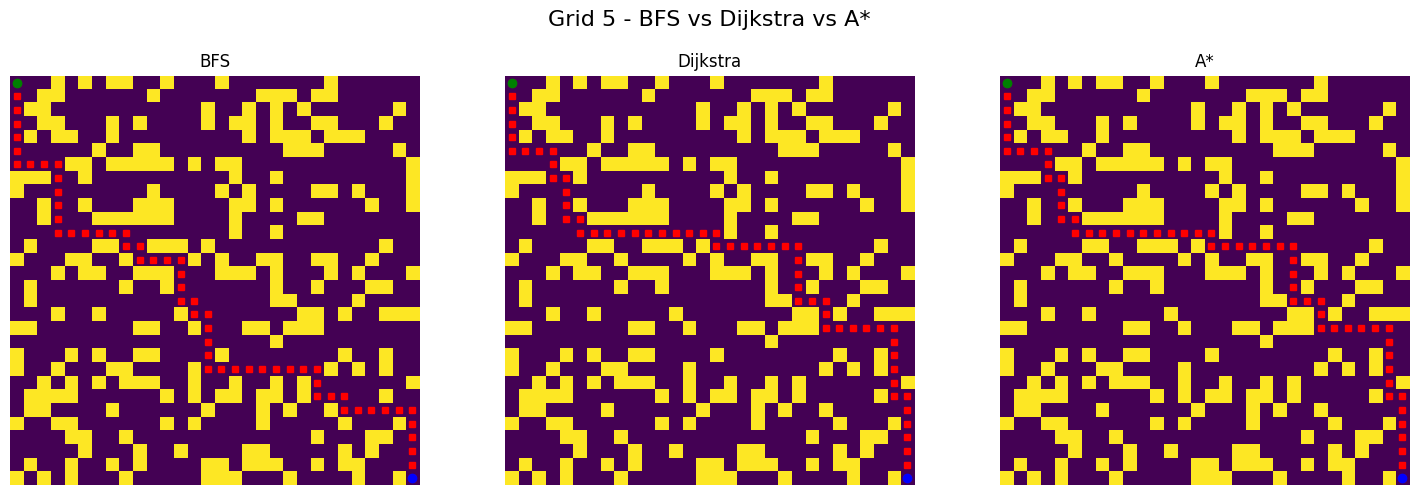

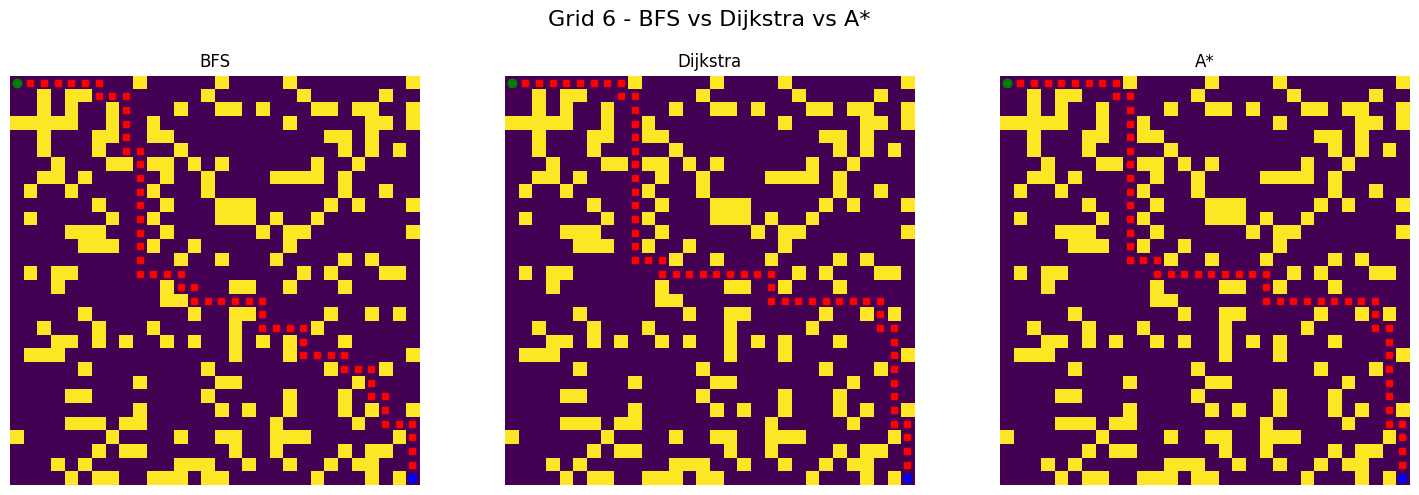

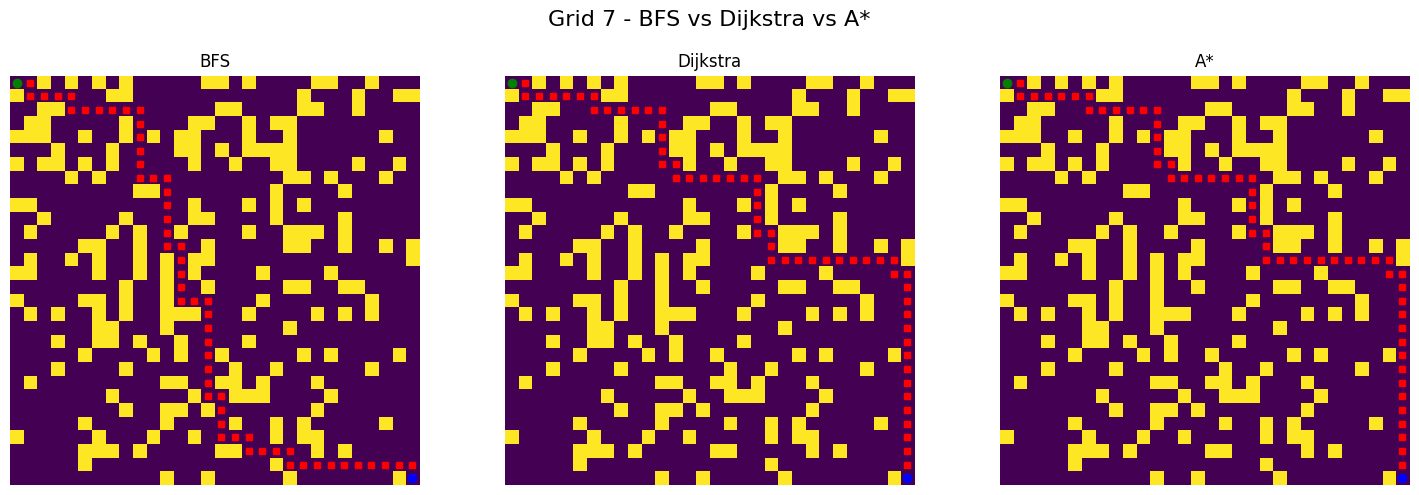

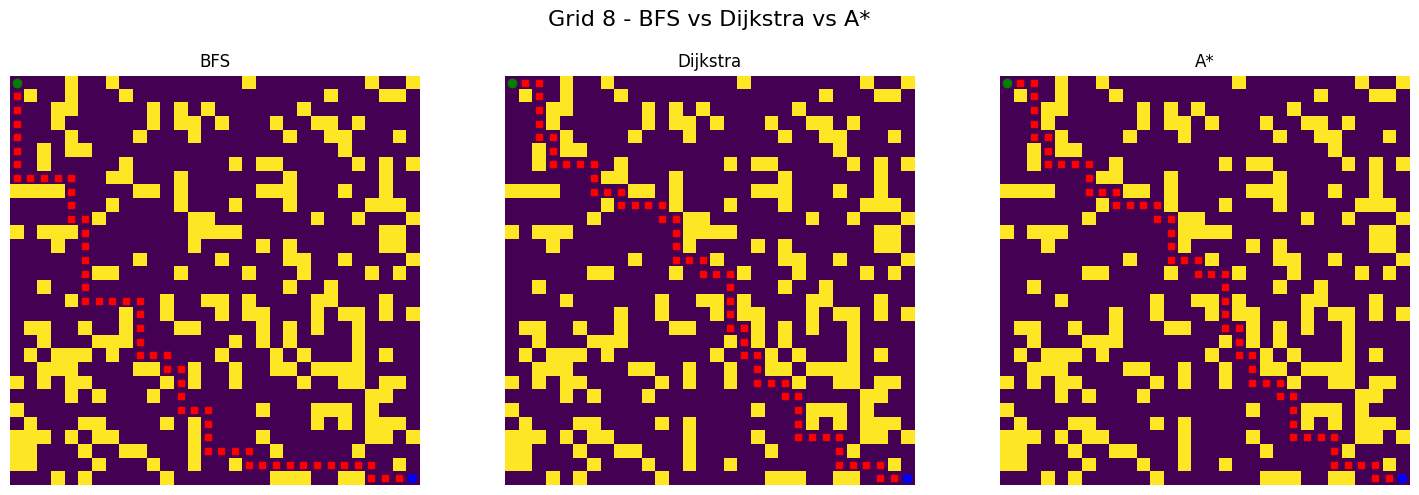

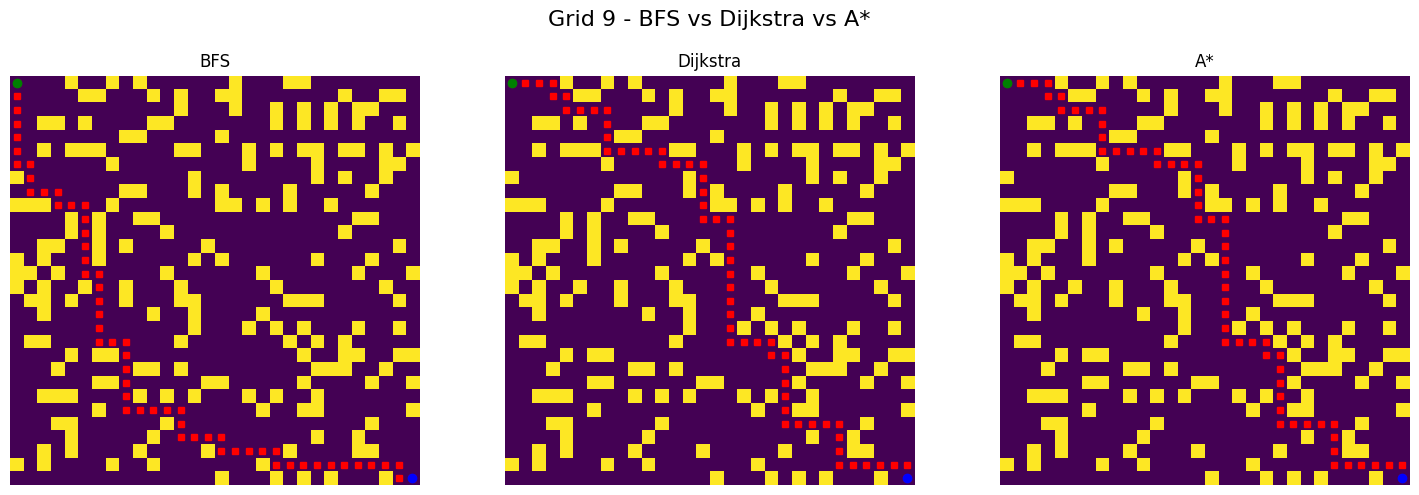

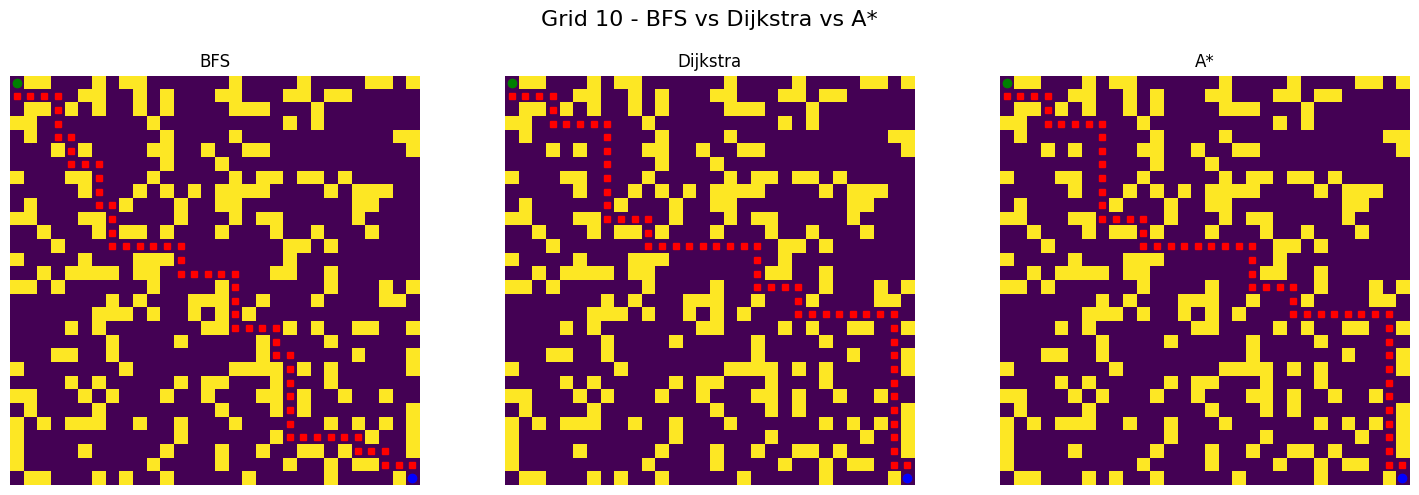

In [13]:
if __name__ == "__main__":
    grids_and_paths, results = evaluate_algorithms(n_grids=10)
    show_all_grids_side_by_side(grids_and_paths)

________________________________________________________________________________________________

## Predicted route using CNN:

### AI predictes the path each algorithm might suggest based on the previously random generated 2D grids. No weighted terrain and stable start and finish points.

The libraries imported now include the ML library PyTorch.

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import numpy as np
import random
import matplotlib.pyplot as plt

from collections import deque
import heapq

________________________________________________________________________________________________

Let's suppose that the experiment is going to take as input a dataset of 500 random generated grids.

In [15]:
GRID_SIZE = 30
OBSTACLE_PROB = 0.25
N_GRIDS = 500

START = (0,0)
GOAL = (GRID_SIZE-1, GRID_SIZE-1)

These grids are generated as follows, always guaranteeing that the start and finish points are walkable.

In [16]:
def generate_grid():

    grid = np.zeros((GRID_SIZE,GRID_SIZE))

    for i in range(GRID_SIZE):
        for j in range(GRID_SIZE):

            if random.random() < OBSTACLE_PROB:
                grid[i][j] = 1

    grid[START] = 0
    grid[GOAL] = 0

    return grid

In [17]:
def get_neighbors(node, grid):

    x,y = node
    neighbors = []

    directions = [(1,0),(-1,0),(0,1),(0,-1)]

    for dx,dy in directions:

        nx = x + dx
        ny = y + dy

        if 0 <= nx < GRID_SIZE and 0 <= ny < GRID_SIZE:
            if grid[nx][ny] == 0:
                neighbors.append((nx,ny))

    return neighbors

In [18]:
def reconstruct_path(came_from):

    path = []
    current = GOAL

    while current != START:
        path.append(current)
        current = came_from[current]

    path.append(START)
    path.reverse()

    return path

________________________________________________________________________________________________

The algorithms should run as for the simple case in each grid.

In [19]:
def bfs(grid):

    queue = deque([START])
    visited = {START}

    came_from = {}

    while queue:

        current = queue.popleft()

        if current == GOAL:
            return reconstruct_path(came_from)

        for n in get_neighbors(current,grid):

            if n not in visited:

                visited.add(n)
                came_from[n] = current
                queue.append(n)

    return None

In [20]:
def dijkstra(grid):

    pq = [(0,START)]

    dist = {START:0}
    came_from = {}

    visited=set()

    while pq:

        cost,current = heapq.heappop(pq)

        if current in visited:
            continue

        visited.add(current)

        if current == GOAL:
            return reconstruct_path(came_from)

        for n in get_neighbors(current,grid):

            new_cost = cost + 1

            if n not in dist or new_cost < dist[n]:

                dist[n] = new_cost
                came_from[n] = current

                heapq.heappush(pq,(new_cost,n))

    return None

In [21]:
def heuristic(a,b):

    return abs(a[0]-b[0]) + abs(a[1]-b[1])


def astar(grid):

    pq=[(0,START)]

    g_cost={START:0}
    came_from={}

    visited=set()

    while pq:

        _,current = heapq.heappop(pq)

        if current in visited:
            continue

        visited.add(current)

        if current == GOAL:
            return reconstruct_path(came_from)

        for n in get_neighbors(current,grid):

            new_g = g_cost[current] + 1

            if n not in g_cost or new_g < g_cost[n]:

                g_cost[n] = new_g

                f = new_g + heuristic(n,GOAL)

                came_from[n] = current

                heapq.heappush(pq,(f,n))

    return None


________________________________________________________________________________________________

All grids must be solvable.

In [22]:
def evaluate_algorithms():

    grids=[]

    while len(grids) < N_GRIDS:

        grid = generate_grid()

        paths = {

            "BFS": bfs(grid),
            "Dijkstra": dijkstra(grid),
            "A*": astar(grid)

        }

        if all(paths.values()):
            grids.append({
                "grid":grid,
                "paths":paths
            })

    return grids

________________________________________________________________________________________________

As for the input dataset used for training and testing, a grid dictionary is created, each containing the grid, the path and the algorithm name.

Then, a 3-channel image of the environment is created, ready for input into a neural network.

In [23]:
def generate_next_move_data(grids,algo):

    X=[]
    y=[]

    for g in grids:

        grid=g["grid"]
        path=g["paths"][algo]

        for i in range(len(path)-1):

            cur=path[i]
            nxt=path[i+1]

            dx=nxt[0]-cur[0]
            dy=nxt[1]-cur[1]

            if dx==-1 and dy==0: move=0
            elif dx==1 and dy==0: move=1
            elif dx==0 and dy==-1: move=2
            elif dx==0 and dy==1: move=3
            else: continue

            tensor=np.zeros((3,GRID_SIZE,GRID_SIZE))

            tensor[0]=(grid==0)
            tensor[1,cur[0],cur[1]]=1
            tensor[2,GOAL[0],GOAL[1]]=1

            X.append(tensor)
            y.append(move)

    X=torch.tensor(np.array(X),dtype=torch.float32)
    y=torch.tensor(y,dtype=torch.long)

    return X,y


class DatasetMoves(Dataset):

    def __init__(self,X,y):
        self.X=X
        self.y=y

    def __len__(self):
        return len(self.X)

    def __getitem__(self,i):
        return self.X[i],self.y[i]



Now, a Convolutional Neural Network (CNN) is defined in order to predict the next move in a grid, based on the 3-channel tensor created earlier.

In [31]:
class CNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = nn.Conv2d(3,16,3,padding=1)
        self.conv2 = nn.Conv2d(16,32,3,padding=1)

        self.fc1 = nn.Linear(32*GRID_SIZE*GRID_SIZE,128)
        self.fc2 = nn.Linear(128,4)

    def forward(self,x):

        x=torch.relu(self.conv1(x))
        x=torch.relu(self.conv2(x))

        x=x.view(x.size(0),-1)

        x=torch.relu(self.fc1(x))

        return self.fc2(x)


Epochs are chosen to be equal to 20 (variable). The optimizeer selected is Adam with an initial learning rate of 0.001. There are also 32 samples per batch.

In [25]:
def train_model(X,y):

    dataset=DatasetMoves(X,y)

    loader=DataLoader(dataset,batch_size=32,shuffle=True)

    model=CNN()

    optimizer=optim.Adam(model.parameters(),lr=0.001)

    loss_fn=nn.CrossEntropyLoss()

    for epoch in range(20):

        total=0

        for xb,yb in loader:

            optimizer.zero_grad()

            pred=model(xb)

            loss=loss_fn(pred,yb)

            loss.backward()

            optimizer.step()

            total+=loss.item()

        print("Epoch",epoch+1,"Loss:",total/len(loader))

    return model


________________________________________________________________________________________________

The trained CNN is used for simulation of the predicted path from start to finish on a given grid.

In [26]:
def simulate_path(model,grid):

    current=START

    path=[current]

    for _ in range(GRID_SIZE*GRID_SIZE):

        if current==GOAL:
            break

        tensor=np.zeros((3,GRID_SIZE,GRID_SIZE))

        tensor[0]=(grid==0)
        tensor[1,current[0],current[1]]=1
        tensor[2,GOAL[0],GOAL[1]]=1

        x=torch.tensor(tensor[np.newaxis],dtype=torch.float32)

        with torch.no_grad():
            move=torch.argmax(model(x)).item()

        dx,dy=0,0

        if move==0: dx=-1
        if move==1: dx=1
        if move==2: dy=-1
        if move==3: dy=1

        nxt=(current[0]+dx,current[1]+dy)

        if 0<=nxt[0]<GRID_SIZE and 0<=nxt[1]<GRID_SIZE and grid[nxt]==0:

            current=nxt
            path.append(current)

        else:
            break

    return path


In order to evaluate the CNN, some different metrics need to be assessed: path similarity, predicted path length error and success rate.

In [27]:
def path_similarity(true,pred):

    return len(set(true)&set(pred)) / len(true)


def path_length_error(true,pred):

    return abs(len(true)-len(pred))


def evaluate_ai(models,grids):

    results={}

    for algo in models:

        success=0
        sim=0
        err=0

        for g in grids:

            grid=g["grid"]
            true=g["paths"][algo]

            pred=simulate_path(models[algo],grid)

            if pred[-1]==GOAL:
                success+=1

            sim+=path_similarity(true,pred)
            err+=path_length_error(true,pred)

        n=len(grids)

        results[algo]={
            "success":success/n,
            "similarity":sim/n,
            "length_error":err/n
        }

    return results

________________________________________________________________________________________________

Of course it is not practical to visualize all 500 grids and the predicted paths on them, so 5 of them are chosen as a demonstation.

On the same grid with different colours are represented the predicted paths for each one of the algorithms.

In [28]:
def visualize(grid,true_paths,ai_paths):

    plt.figure(figsize=(6,6))

    plt.imshow(grid,cmap="gray_r")

    colors={"BFS":"red","Dijkstra":"orange","A*":"purple"}

    for algo in true_paths:

        t=true_paths[algo]
        p=ai_paths[algo]

        xs=[x for x,_ in t]
        ys=[y for _,y in t]

        plt.plot(ys,xs,"--",color=colors[algo],label=algo+" True")

        xs=[x for x,_ in p]
        ys=[y for _,y in p]

        plt.plot(ys,xs,color=colors[algo],label=algo+" AI")

    plt.scatter(START[1],START[0],c="green",s=80,label="Start")
    plt.scatter(GOAL[1],GOAL[0],c="blue",s=80,label="Goal")

    plt.legend()

    plt.show()


Training BFS
Epoch 1 Loss: 0.6029803048198422
Epoch 2 Loss: 0.23881772733620255
Epoch 3 Loss: 0.16454542784036644
Epoch 4 Loss: 0.12830019232269638
Epoch 5 Loss: 0.10282220521644615
Epoch 6 Loss: 0.08150803656079868
Epoch 7 Loss: 0.06655406101778856
Epoch 8 Loss: 0.05018080942445841
Epoch 9 Loss: 0.0392407497102045
Epoch 10 Loss: 0.02755954463926875
Epoch 11 Loss: 0.020431105798467655
Epoch 12 Loss: 0.019538927361531136
Epoch 13 Loss: 0.014169426613025999
Epoch 14 Loss: 0.014954825941289161
Epoch 15 Loss: 0.007616232706795289
Epoch 16 Loss: 0.010620136181425746
Epoch 17 Loss: 0.008215888870088412
Epoch 18 Loss: 0.007493382071608697
Epoch 19 Loss: 0.006271807859952199
Epoch 20 Loss: 0.0050461150217557815

Training Dijkstra
Epoch 1 Loss: 0.6329610202820939
Epoch 2 Loss: 0.23625874605944805
Epoch 3 Loss: 0.16787684581695908
Epoch 4 Loss: 0.13668168852669432
Epoch 5 Loss: 0.1123326425233819
Epoch 6 Loss: 0.08780683568891204
Epoch 7 Loss: 0.06766965552199972
Epoch 8 Loss: 0.054019771648439

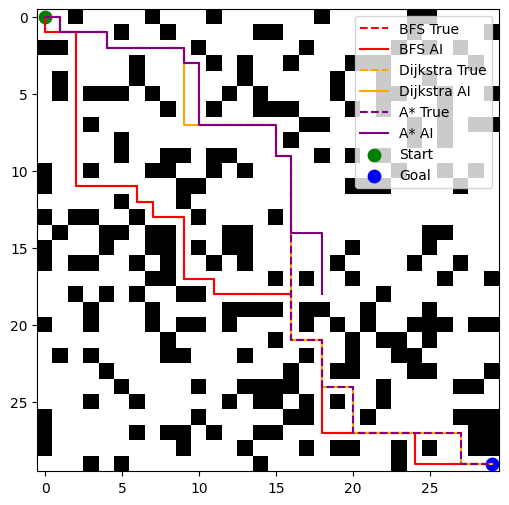

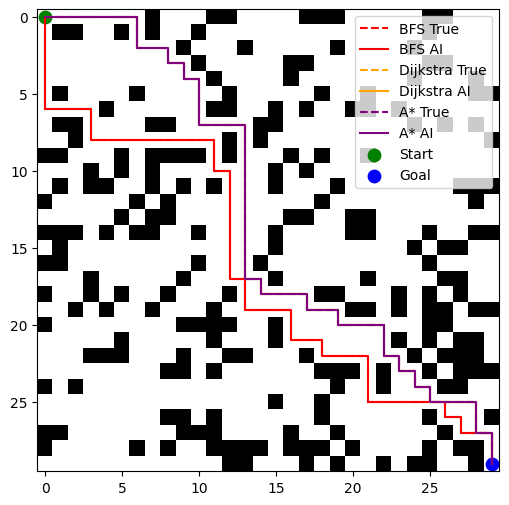

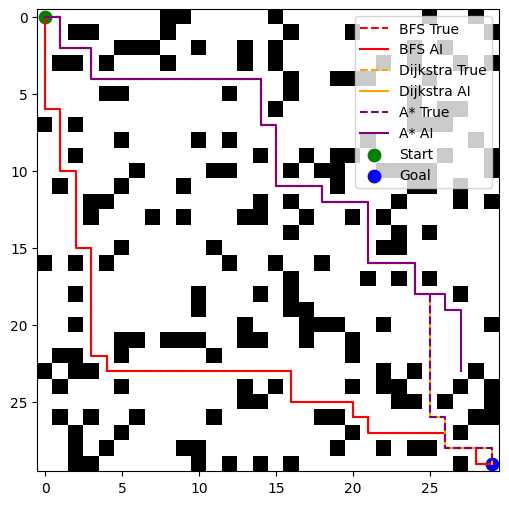

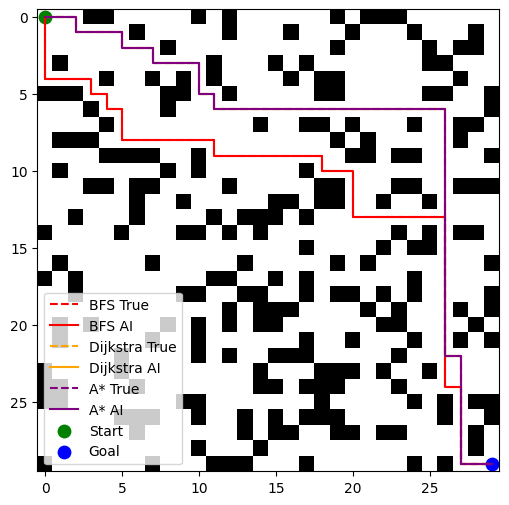

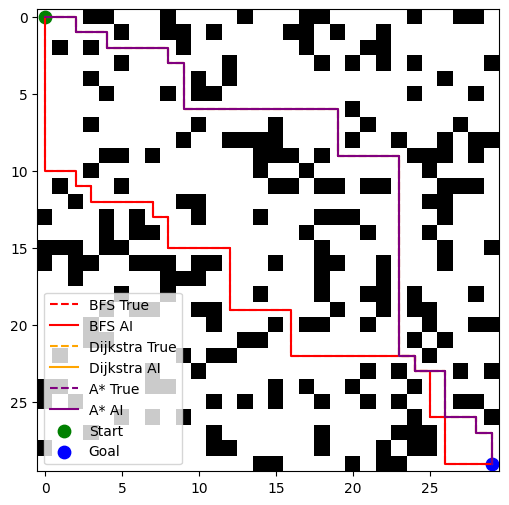

In [29]:
grids=evaluate_algorithms()

models={}

for algo in ["BFS","Dijkstra","A*"]:

    print("\nTraining",algo)

    X,y=generate_next_move_data(grids,algo)

    models[algo]=train_model(X,y)

results=evaluate_ai(models,grids)

print("\nAI PERFORMANCE\n")

for k,v in results.items():

    print(k)
    print("Success Rate:",v["success"])
    print("Path Similarity:",v["similarity"])
    print("Length Error:",v["length_error"])
    print()


sample=random.sample(grids,5)

for g in sample:

    grid=g["grid"]

    ai_paths={
        algo:simulate_path(models[algo],grid)
        for algo in models
    }

    visualize(grid,g["paths"],ai_paths)

The paths predicted for Dijkstra and A* are often the same in route, that is why their colours overlap in the visualisation.